In [1]:
from algorithms import *
from simulation import *
import numpy as np
from PIL import Image
import seaborn as sns
import skimage
import os
import matplotlib.pyplot as plt
sns.set_style("whitegrid")  
sns.set(font_scale=1.5)

In [2]:
cPath = r'./data/'
signal = []
cfile = os.listdir(cPath)
for f in cfile:
    if f[-1] == 'g':
        im = Image.open(cPath + f)
        im = (np.array(im)-127.5)/255
        signal.append(im)

In [3]:
target_id = 225
p = 150
q = 150
p0 = 40
q0 = 40
ri = 20
K = 1
Sscale = 1 
idx_list, yk_list = generate_kfold_observations(signal[target_id:target_id+1],6000,1,K,p,q)
idx_target = list(chain.from_iterable(idx_list[0][i] for i in range(len(idx_list[0]))))
y_target = list(chain.from_iterable(yk_list[0][i] for i in range(len(yk_list[0]))))

# one-way or two-way representations

In [4]:
import numpy as np
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt


def one_way_regression_left(R, C, idx_list, y):
    n = len(y)
    p, p0 = R.shape
    q, q0 = C.shape 
    
    f = []
    for i in range(n):
        X = idx_to_matrix(p, q, idx_list[i])
        Z_tilde = R.T @ X 
        
        f.append(Z_tilde.reshape(p0 * q,))
    
    F_tilde = (LinearRegression(fit_intercept=False).fit(f, y).coef_).reshape(p0, q)
    return R @ F_tilde

def one_way_regression_right(R, C, idx_list, y):
    n = len(y)
    p, p0 = R.shape
    q, q0 = C.shape
    
    f = []
    for i in range(n):
        X = idx_to_matrix(p, q, idx_list[i])
        Z_tilde = X @ C
        
        f.append(Z_tilde.reshape(p * q0,))
    
    F_tilde = (LinearRegression(fit_intercept=False).fit(f, y).coef_).reshape(p, q0)
    
    return F_tilde @ C.T

In [5]:
debiased_matrices = signal[:50]
R, C = PCA2D2(debiased_matrices, p0, q0)

m_bidirectional = feature_finetune(R, C, idx_target, y_target)

m_row_only = one_way_regression_left(R, C, idx_target, y_target)

m_col_only = one_way_regression_right(R, C, idx_target, y_target)

<>:4: SyntaxWarning: invalid escape sequence '\L'
<>:7: SyntaxWarning: invalid escape sequence '\L'
<>:4: SyntaxWarning: invalid escape sequence '\L'
<>:7: SyntaxWarning: invalid escape sequence '\L'
/var/folders/99/bb8jj3k54_gcfywdk0t1gpzc0000gn/T/ipykernel_4058/3183348659.py:4: SyntaxWarning: invalid escape sequence '\L'
  plt.title("Row-wise Only ($R \Lambda_R$)",fontsize=27)
/var/folders/99/bb8jj3k54_gcfywdk0t1gpzc0000gn/T/ipykernel_4058/3183348659.py:7: SyntaxWarning: invalid escape sequence '\L'
  plt.title("Col-wise Only ($\Lambda_C C^T$)",fontsize=27)


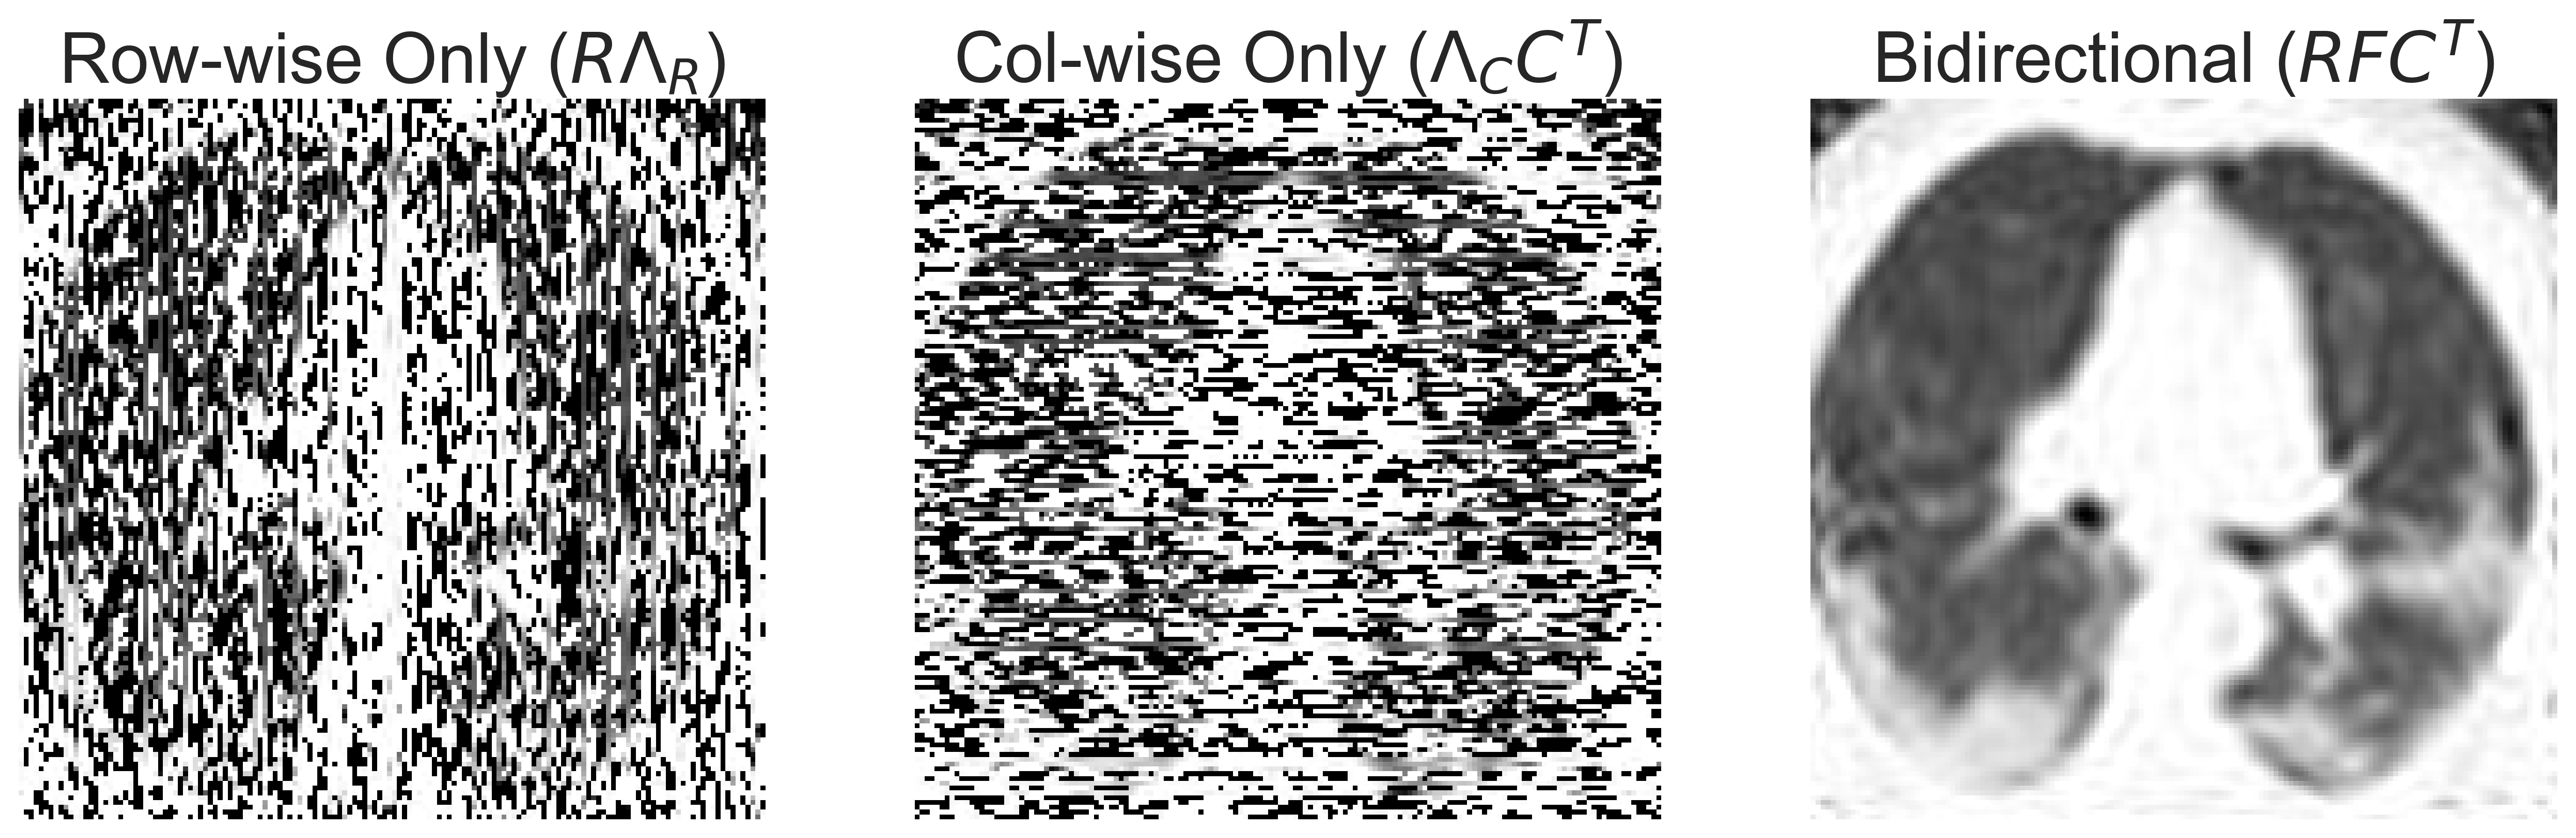

In [6]:
plt.figure(figsize=(17.5, 5),dpi=400)
plt.subplot(1, 3, 1)
sns.heatmap(m_row_only,cmap="grey",xticklabels=[], yticklabels=[], cbar=False,vmax=0.5,vmin=-0.5)
plt.title("Row-wise Only ($R \Lambda_R$)",fontsize=27)
plt.subplot(1, 3, 2)
sns.heatmap(m_col_only,cmap="grey",xticklabels=[], yticklabels=[], cbar=False,vmax=0.5,vmin=-0.5)
plt.title("Col-wise Only ($\Lambda_C C^T$)",fontsize=27)
plt.subplot(1, 3, 3)
sns.heatmap(m_bidirectional,cmap="grey",xticklabels=[], yticklabels=[], cbar=False,vmax=0.5,vmin=-0.5)
plt.title("Bidirectional ($R F C^T$)",fontsize=27)

plt.savefig('one-or-two-99.png', bbox_inches='tight')